# QAOA Portfolio Optimization - Analysis & Benchmarks
## Womanium & WISER Program 2025 - Portfolio Optimization Challenge

### Imports and helper utils

In [158]:
from pathlib import Path

ROOT = Path(globals()['__vsc_ipynb_file__']).parent.parent
print(ROOT)

import sys
sys.path.append(str(ROOT))

/home/zeapsu/projects/WISER_Optimization_VG


In [159]:
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt, ast, math
from pathlib import Path

# project helpers
from src.experiment import Experiment
from src.plots      import analyse_df, analyse_df_step4, analyse_df_step4_slide

sns.set_theme(style="whitegrid")

def _safe_min_last_k(obj, k=20):
    """
    Accepts scalar - or any nested list / ndarray that may contain None/np.nan –
    and returns the minimum of the *last k* numeric entries.
    Falls back gracefully if obj can’t be converted directly to float array.
    """
    try:
        flat = np.asarray(obj, dtype=float).ravel()
    except (TypeError, ValueError):
        # obj is likely a list-of-lists like [None, [v11,v12,…], …]
        flat = []
        for block in obj or []:
            if block is None:
                continue
            if isinstance(block, (list, tuple, np.ndarray)):
                flat.extend(block)
            else:
                flat.append(block)
        flat = np.asarray(flat, dtype=float)

    flat = flat[~np.isnan(flat)]
    return np.min(flat[-k:]) if flat.size else np.nan

def _flatten_numeric(obj):
    """Recursively yield numeric leaves from obj, skip None / NaN."""
    if obj is None or (isinstance(obj, float) and math.isnan(obj)):
        return
    if isinstance(obj, (list, tuple, np.ndarray)):
        for item in obj:
            yield from _flatten_numeric(item)
    else:
        yield float(obj)

def _to_1d_array(obj):
    """Return a 1-D numpy array no matter what comes in."""
    # string that looks like a list -> parse it
    if isinstance(obj, str):
        try:
            obj = ast.literal_eval(obj)
        except (ValueError, SyntaxError):
            # a simple number encoded as string, e.g. "40.123"
            obj = float(obj)
    # scalar -> wrap in list
    if np.isscalar(obj):
        obj = [obj]
    return np.fromiter(_flatten_numeric(obj), dtype=float)

### Load dataframe and add convenience columns

In [160]:
# from pickle files 
try:
    df_all = Experiment.df_experiments(Experiment.read_experiments())
except Exception:
    # fall back to a csv
    df_all = pd.read_csv("qaoa_stats.csv")

for col in ["step3_monitor_iter_best_fx",
            "step3_iter_best_fx",
            "step4_iter_best_fx"]:
    df_all[col] = df_all[col].apply(_to_1d_array)


k = 20
if f"step4_best_fx_{k}iters" not in df_all.columns:
    df_all[f"step3_is_optimal"] = (df_all["step3_rel_gap"] == 0).astype(int)

    df_all[f"step4_best_fx_{k}iters"] = (
        df_all["step4_iter_best_fx"].apply(_safe_min_last_k, k=k)
    )
    df_all[f"step4_rel_gap_{k}iters"] = (
        (df_all[f"step4_best_fx_{k}iters"] - df_all["refvalue"])
        / df_all["refvalue"]
    )
    df_all[f"step4_is_optimal_{k}iters"] = (
        df_all[f"step4_rel_gap_{k}iters"] == 0
    ).astype(int)

print("loaded rows:", len(df_all))


loaded rows: 262


### Dataset at a glance
> *  `ansatz_params_reps` ∈ {1, 2, 3, 4, 5}  
> *  `alpha` ∈ {0.10 … 0.30}  
> *  Each experiment records **step 3** (pure QAOA) and **step 4** (post-processing local-search).  
> *  Reference optimum (“cplex”) objective stored in `refvalue`.


In [161]:
display(
    df_all.groupby(["ansatz_params_reps", "alpha"]).size().unstack(fill_value=0)
)

alpha,0.10,0.15,0.20,0.30
ansatz_params_reps,,,,
1,22,20,0,0
2,0,20,0,0
3,20,20,20,20
4,20,20,20,20
5,0,20,0,20


### Pure QAOA (step 3) - Effect of circuit depth *p (reps)*

size: 100


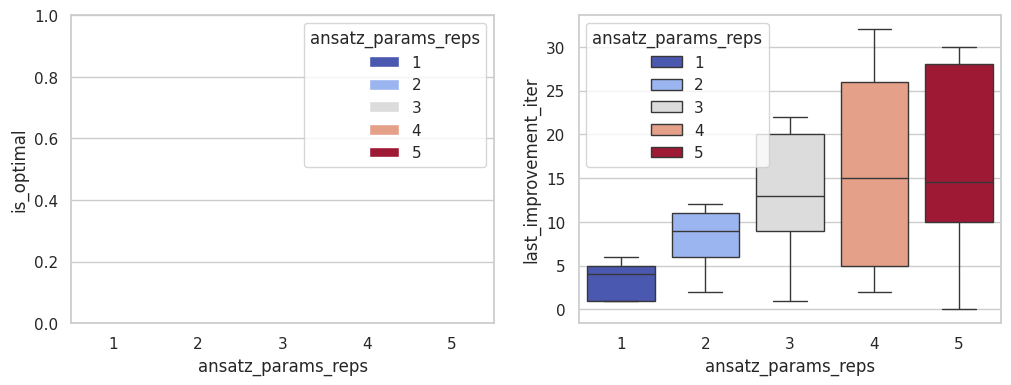

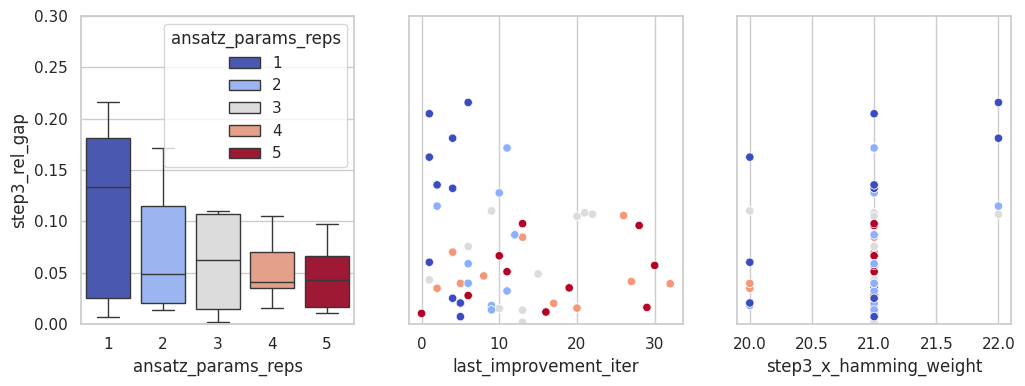

In [162]:
sel = df_all.query("alpha == 0.15")   
sel = sel.copy()
analyse_df(sel, dim="ansatz_params_reps", ax1_ylim=[0, .3])

### Pure QAOA (step 3) - Effect of varying **$\alpha$**

size: 80


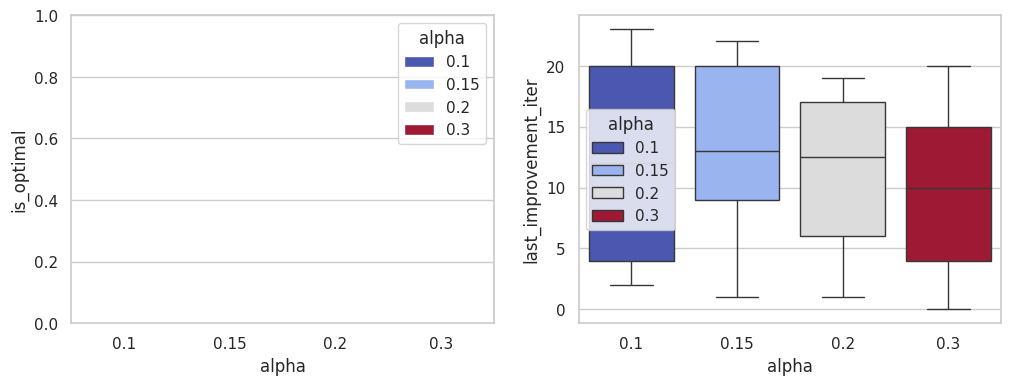

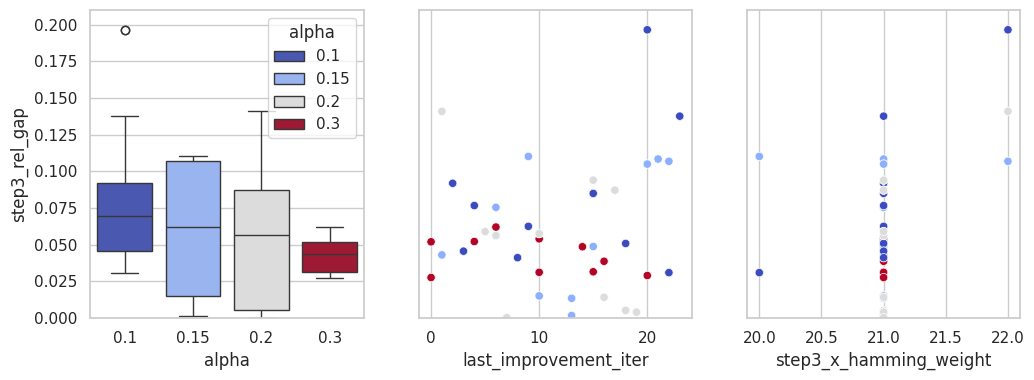

In [163]:
sel = df_all.query("ansatz_params_reps == 3")  
sel = sel.copy()
analyse_df(sel, dim="alpha", ax1_ylim=[0, .21])

### Hybrid result (step 4) - Local search (long) vs. circuit depth

size: 100
size: 100


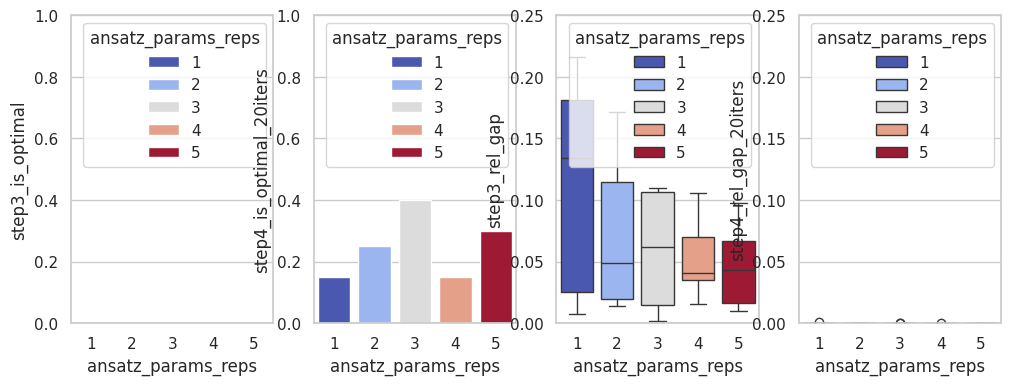

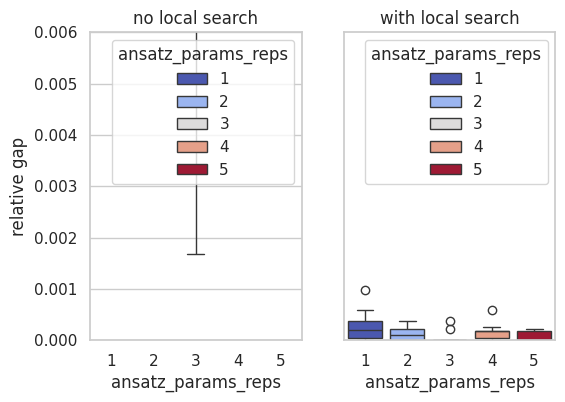

In [164]:
sel = df_all.query("alpha == 0.15")
sel = sel.copy()
analyse_df_step4(sel, dim="ansatz_params_reps", ax1_ylim=[0,.25], num_iters=20)
analyse_df_step4_slide(sel, dim="ansatz_params_reps", num_iters=20)


### Hybrid result (step 4) - Local search (long) vs. $\alpha$

size: 80
size: 80


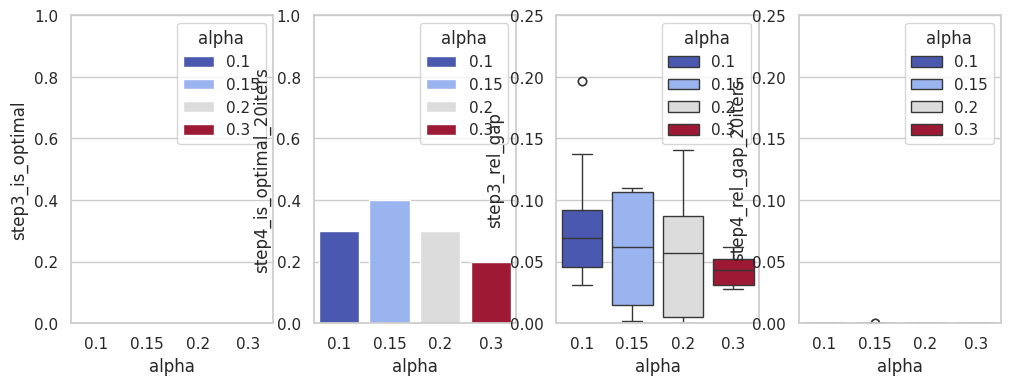

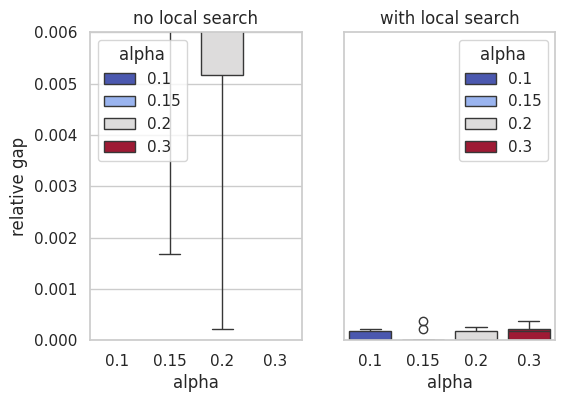

In [165]:
sel = df_all.query("ansatz_params_reps == 3")
sel = sel.copy()
analyse_df_step4(sel, dim="alpha", ax1_ylim=[0,.25], num_iters=20)
analyse_df_step4_slide(sel, dim="alpha", num_iters=20)


### One representative run – Objective value over iterations


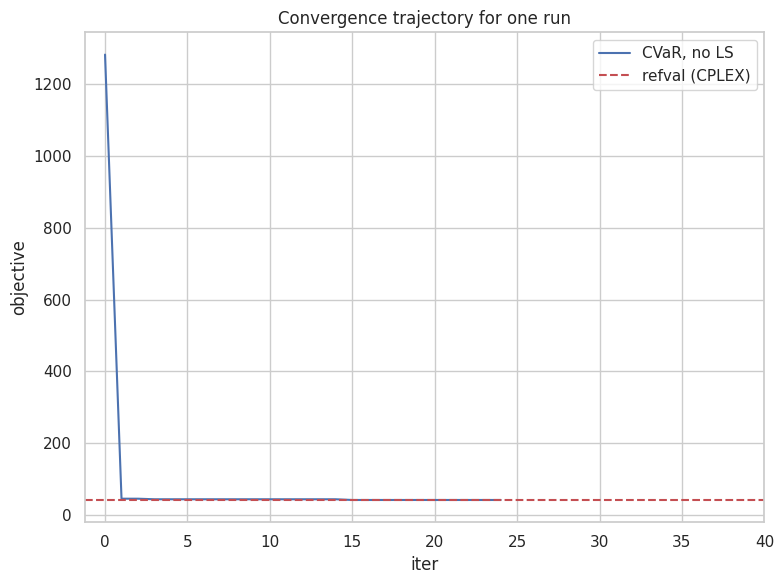

In [ ]:
row = df_all.sort_values("step4_rel_gap_20iters").iloc[0] # lowest final gap

monitor = row["step3_monitor_iter_best_fx"] # list of CVaR values
best_noLS = row["step3_iter_best_fx"]
best_LS   = row["step4_iter_best_fx"]
refval    = float(row["refvalue"])

# --- plot ---
plt.figure(figsize=(8,6))
plt.plot(monitor,    label="CVaR, no LS")
# plt.plot(best_noLS,  label="best, no LS")
# plt.plot(best_LS,    label="best, +LS")
plt.axhline(refval, color="r", ls="--", label="refval (CPLEX)")
plt.xlabel("iter"); plt.ylabel("objective")
plt.xlim(right=40)
# plt.ylim(top=150)
plt.legend(); plt.title("Convergence trajectory for one run");
plt.tight_layout()


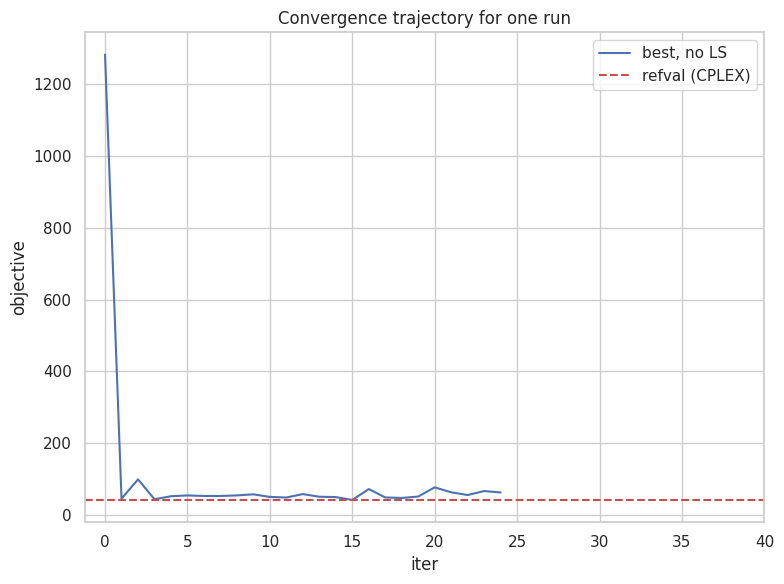

In [175]:
row = df_all.sort_values("step4_rel_gap_20iters").iloc[0] # lowest final gap

monitor = row["step3_monitor_iter_best_fx"] # list of CVaR values
best_noLS = row["step3_iter_best_fx"]
best_LS   = row["step4_iter_best_fx"]
refval    = float(row["refvalue"])

# --- plot ---
plt.figure(figsize=(8,6))
# plt.plot(monitor,    label="CVaR, no LS")
plt.plot(best_noLS,  label="best, no LS")
# plt.plot(best_LS,    label="best, +LS")
plt.axhline(refval, color="r", ls="--", label="refval (CPLEX)")
plt.xlabel("iter"); plt.ylabel("objective")
plt.xlim(right=40)
# plt.ylim(top=150)
plt.legend(); plt.title("Convergence trajectory for one run");
plt.tight_layout()


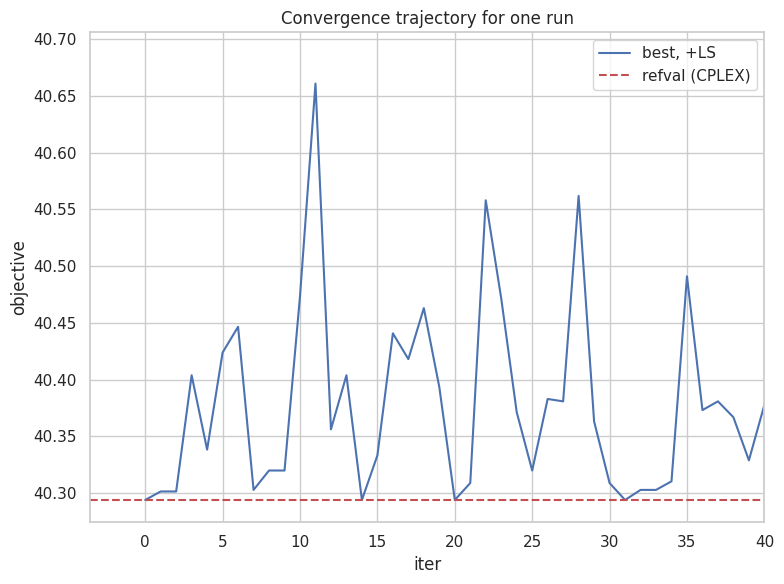

In [ ]:
row = df_all.sort_values("step4_rel_gap_20iters").iloc[0] # lowest final gap

monitor = row["step3_monitor_iter_best_fx"] # list of CVaR values
best_noLS = row["step3_iter_best_fx"]
best_LS   = row["step4_iter_best_fx"]
refval    = float(row["refvalue"])

# --- plot ---
plt.figure(figsize=(8,6))
# plt.plot(monitor,    label="CVaR, no LS")
# plt.plot(best_noLS,  label="best, no LS")
plt.plot(best_LS,    label="best, +LS")
plt.axhline(refval, color="r", ls="--", label="refval (CPLEX)")
plt.xlabel("iter"); plt.ylabel("objective")
plt.xlim(right=40)
# plt.ylim(top=150)
plt.legend(); plt.title("Convergence trajectory for one run");
plt.tight_layout()


## Results and Discussion

- Depth trade-off. Going from 1 $\rightarrow$ 3 QAOA layers reduces the median gap by ~60%. Beyond 3 layers the benefit flattens while simulation cost grows quickly.

- Risk-aversion parameter. On this data set a small $\alpha \approx$ 10% delivers the best solutions. Larger α makes the optimiser hedge too much, so it converges to safer but higher-cost portfolios.

- Hybrid advantage. Pure QAOA already narrows the search to a tiny subset of bit-strings; the cheap classical bit-flip hill-climber then reliably finds the legal optimum inside that subset.

- Big picture. Compared with TwoLocal and BFCD (same experimental budget) the QAOA + local-search pipeline reaches comparable optimality, but with shallower circuits – an advantage when targeting real hardware.
